In [11]:
# Import packages

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tkinter import Tk, filedialog
import matplotlib.ticker as ticker

In [7]:
### INPUT USER ----------------
avg_folder = "/Users/laureleblanc/Desktop/Collective-twitching-2026/5_competition_assay/dataset/mean_curve"
ind_folder = "/Users/laureleblanc/Desktop/Collective-twitching-2026/5_competition_assay/dataset/individual_curve"
output_folder = "/Users/laureleblanc/Desktop/Collective-twitching-2026/5_competition_assay/figures"
#------------------------------

# Plot bacterial numbers as a function of distance to the colony front

6_2619+2624_30min.csv


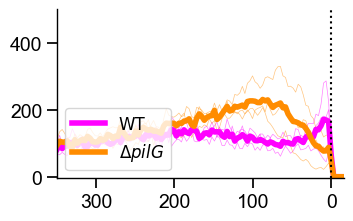

7_2619+2624_1h30.csv


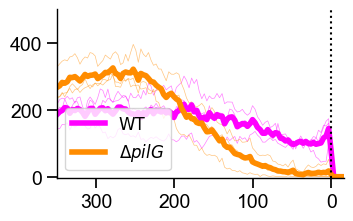

3_2619+2621_1h30.csv


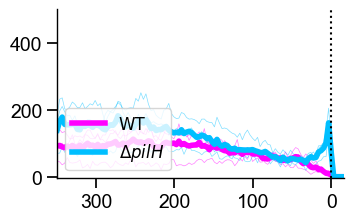

8_2619+2624_2h30.csv


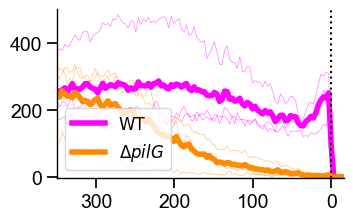

5_2619+2624_10min.csv


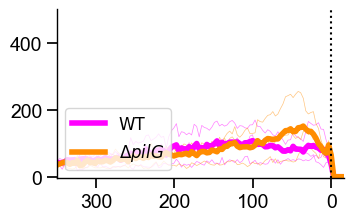

4_2619+2621_2h30.csv


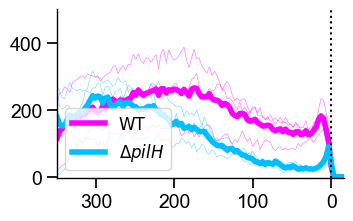

1_2619+2621_10min.csv


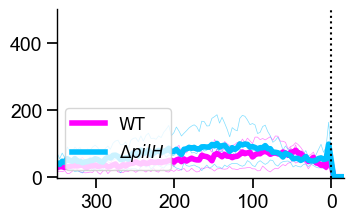

2_2619+2621_30min.csv


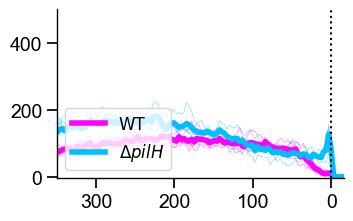

In [8]:
# Select folders
def select_folder(prompt="Select folder"):
    root = Tk()
    root.withdraw()
    folder_selected = filedialog.askdirectory(title=prompt)
    return folder_selected

# Plotting and saving
for filename in os.listdir(avg_folder):
    print(filename)
    if not filename.endswith(".csv"):
        continue

    avg_path = os.path.join(avg_folder, filename)
    ind_path = os.path.join(ind_folder, filename)

    if not os.path.exists(ind_path):
        print(f"Missing individual file for: {filename}")
        continue

    # Load data
    df_avg = pd.read_csv(avg_path)
    df_ind = pd.read_csv(ind_path)

    # Determine green label based on filename
    # Strain label logic (for legend)
    if '2621' in filename:
        green_label = r'$\Delta\mathit{pilH}$'
        color = 'deepskyblue'
    elif '2624' in filename:
        green_label = r'$\Delta\mathit{pilG}$'
        color = 'darkorange'
    elif '2622' in filename:
        green_label = r'$\Delta\mathit{pilH}$'
        color = 'deepskyblue'
    elif '3136' in filename:
        green_label = r'$\Delta\mathit{lasR}$'
        color = 'lightgreen'
    else:
        green_label = 'Mutant'

    # Set up figure
    fig, ax = plt.subplots(figsize=(3.7, 2.2))
    #fig, ax = plt.subplots(figsize=(4, 4))

    # Plot individual curves (thin)
    for col in df_ind.columns:
        if col.startswith("red"):
            ax.plot(df_ind['Abscissa'], df_ind[col], color='magenta', linewidth=0.5, alpha=0.5)
        elif col.startswith("green"):
            ax.plot(df_ind['Abscissa'], df_ind[col], color=color, linewidth=0.5, alpha=0.5)

    # Plot average curves (thick)
    if 'red_mean' in df_avg.columns:
        ax.plot(df_avg['Abscissa'], df_avg['red_mean'], color='magenta', linewidth=4, label='WT')
    if 'green_mean' in df_avg.columns:
        ax.plot(df_avg['Abscissa'], df_avg['green_mean'], color=color, linewidth=4, label=green_label)

    # Formatting
    ax.axvline(x=0, color='black', linestyle=':', linewidth=1.5)
    ax.set_xlim(350, -16)
    ax.set_ylim(-5, 500)
    ax.set_xlabel('') #"Distance from the edge (µm)", fontsize=16, fontweight='bold', fontname='Arial')
    #ax.set_ylabel("Number of bacteria", fontsize=16, fontweight='bold', fontname='Arial')
    ax.xaxis.set_major_locator(ticker.FixedLocator([0, 100, 200, 300]))
    ax.legend(loc = 'lower left', fontsize=12, frameon = True) #False, bbox_to_anchor = (-0.01, 1.2))
    ax.tick_params(axis='both', which='major', length=7, width=1.25, color='black')
    ax.tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
    ax.tick_params(axis='both', labelsize=14)
    ax.spines['top'].set_linewidth(False)
    ax.spines['right'].set_linewidth(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    #plt.tight_layout()

    # Save
    base_name = filename.replace('.csv', '')
    for ext in ['png']:
        out_path = os.path.join(output_folder, f"{base_name}.{ext}")
        plt.savefig(out_path, dpi=300, transparent=True, bbox_inches='tight')
        
    plt.show()
    plt.close()


# Plot relative abundance as a function of distance to the colony front

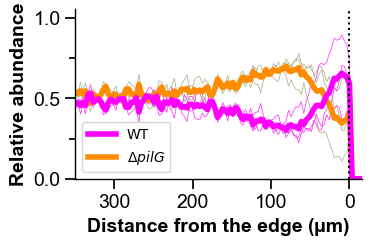

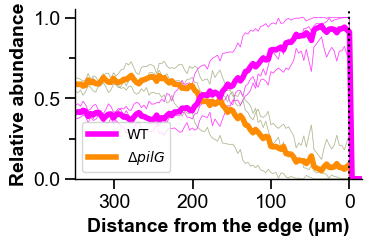

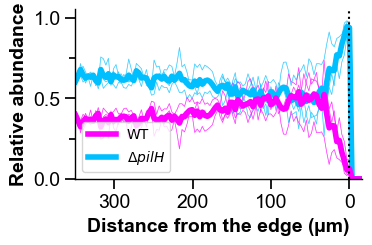

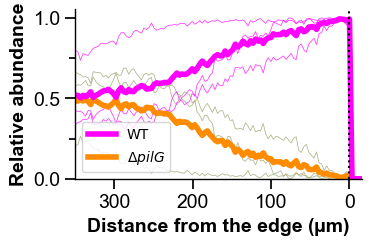

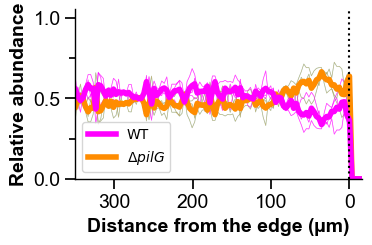

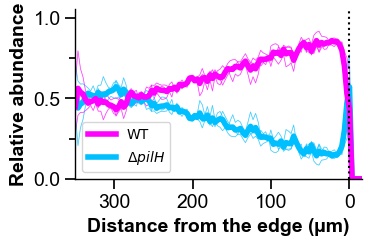

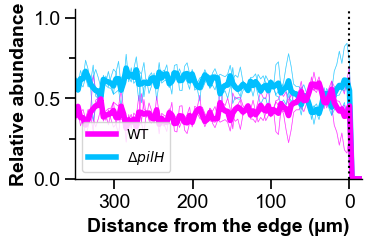

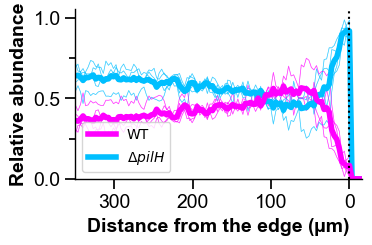

In [12]:
# Plot figures 

for filename in os.listdir(ind_folder):
    if not filename.endswith(".csv"):
        continue

    ind_path = os.path.join(ind_folder, filename)
    df = pd.read_csv(ind_path)

    # Get column suffixes shared by red and green
    red_cols = [col for col in df.columns if col.startswith("red")]
    green_cols = [col for col in df.columns if col.startswith("green")]
    suffixes = sorted(set(col[3:] for col in red_cols) & set(col[5:] for col in green_cols))

    abscissa = df['Abscissa']
    red_rel_curves = []
    green_rel_curves = []

    # Compute relative curves
    for suf in suffixes:
        red_vals = df[f'red{suf}']
        green_vals = df[f'green{suf}']
        total = red_vals + green_vals
        with np.errstate(divide='ignore', invalid='ignore'):
            red_rel = np.where(total != 0, red_vals / total, 0)
            green_rel = np.where(total != 0, green_vals / total, 0)

        red_rel_curves.append(red_rel)
        green_rel_curves.append(green_rel)

    # Convert to DataFrames
    df_red = pd.DataFrame(red_rel_curves).T
    df_green = pd.DataFrame(green_rel_curves).T

    # Plot
    fig, ax = plt.subplots(figsize=(3.7, 2.2))
    
    # Strain label logic (for legend)
    if '2621' in filename:
        green_label = r'$\Delta\mathit{pilH}$'
        color = 'deepskyblue'
    elif '2624' in filename:
        green_label = r'$\Delta\mathit{pilG}$'
        color = 'darkorange'
    elif '2622' in filename:
        green_label = r'$\Delta\mathit{pilH}$'
        color = 'deepskyblue'
    else:
        green_label = 'Mutant'

    # Individual curves
    for col in df_red.columns:
        ax.plot(abscissa, df_red[col], color='magenta', linewidth=0.5, alpha=0.5)
    for col in df_green.columns:
        ax.plot(abscissa, df_green[col], color='deepskyblue', linewidth=0.5, alpha=0.5)

    # Mean curves
    red_mean = df_red.mean(axis=1, skipna=True)
    green_mean = df_green.mean(axis=1, skipna=True)
    ax.plot(abscissa, red_mean, color='magenta', linewidth=3, label='WT')
    ax.plot(abscissa, green_mean, color='deepskyblue', linewidth=3, label='Mutant')
    
    # Individual curves (thin lines, no label)
    # Plot all green individual curves first (thin lines)
    for col in df_green.columns:
        ax.plot(abscissa, df_green[col], color=color, linewidth=0.5, alpha=0.5)

    # Then plot all red individual curves (thin lines) on top
    for col in df_red.columns:
        ax.plot(abscissa, df_red[col], color='magenta', linewidth=0.5, alpha=0.5)


    # Mean curves (thick lines with legend labels)
    red_mean = df_red.mean(axis=1, skipna=True)
    green_mean = df_green.mean(axis=1, skipna=True)

    # Plot thick mean curves: green first, then red on top
    green_line, = ax.plot(abscissa, green_mean, color=color, linewidth=4, label=green_label)
    red_line, = ax.plot(abscissa, red_mean, color='magenta', linewidth=4, label='WT')


    # Add legend only for thick lines
    ax.legend(handles=[red_line, green_line], loc='lower left', fontsize=10, frameon =  True) #False, bbox_to_anchor = (-0.01, 1.2))


    # Formatting
    ax.axvline(x=0, color='black', linestyle=':', linewidth=1.5)
    ax.set_xlim(350, -16)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Distance from the edge (µm)", fontsize=14, fontweight='bold', fontname='Arial')
    ax.set_ylabel("Relative abundance", fontsize=14, fontweight='bold', fontname='Arial')
    ax.xaxis.set_major_locator(ticker.FixedLocator([0, 100, 200, 300]))
    ax.yaxis.set_major_locator(ticker.FixedLocator([0.0, 0.5, 1.0]))
    ax.yaxis.set_minor_locator(ticker.FixedLocator([0.25, 0.75]))
    ax.tick_params(axis='both', which='major', length=7, width=1.25, color='black')
    ax.tick_params(axis='both', which='minor', length=4, width=1.25, color='black')
    ax.tick_params(axis='both', labelsize=14)
    ax.spines['top'].set_linewidth(False)
    ax.spines['right'].set_linewidth(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    #plt.tight_layout()

    # Save
    base_name = filename.replace('.csv', '') + "_relative_abundance"
    for ext in ['png']:
        out_path = os.path.join(output_folder, f"{base_name}.{ext}")
        plt.savefig(out_path, dpi=300, transparent=True, bbox_inches='tight')

    plt.show()
    plt.close()
